# Climatology of CSHT in $\sigma$ layers

This will be used to separate the mean and eddy heat transport components

In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers = 48)

In [3]:
	#session = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
	session = cc.database.create_session('/home/156/wf4500/databases/access/panan01_paralelrun_HT.db') #panan01
	
	start_time='1999-01-01'     
	end_time='2001-12-31'
	#Start_time0 and end_time0 are for importing the daily transport, and it ahsthe number of days in the month    
	start_time0='1999-01-01'     
	end_time0='2001-12-31'
	print(start_time0) 
	print(end_time0) 
	exp = 'panan01_yr2000_HTsigma'
	
	print("Start date =" + start_time) 
	year2=str(int(start_time[0:4])+1)
	month2=str(int(start_time[5:7])+1)
	month2=str(int(month2))
	month2 = month2.zfill(2)    
	print("month2 is =" + month2) 
	print("year2 is =" + str(year2))     
	
	print("End date =" + end_time) 
	
	
	time_period = str(int(start_time[:4]))+'-'+str(int(end_time[:4]))
	
	# reference density value:
	rho_0 = 1035.0
	# specific heat capacity of sea water:
	cp = 3992.1
	lat_range = slice(-90,-59)
	
	isobath_depth = 1000
	
	# pick a freezing point temp:
	temp_freezing = -1.9
	

1999-01-01
2001-12-31
Start date =1999-01-01
month2 is =02
year2 is =2000
End date =2001-12-31


In [4]:
	
	print("importing T_adx and T_ady")
	
	#importing all heat transports calculated offline
	temp_xflux = cc.querying.getvar(exp,'T_adx',session,ncfile='%month_rho%',start_time=start_time[:-3],end_time=end_time[:-3])

	ndays_month=int(np.size(temp_xflux.time))
	

importing T_adx and T_ady


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [23]:
	#getting transports 
	
	vhrho_nt = cc.querying.getvar(exp,'vmo',session,ncfile='%month_rho%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	uhrho_et = cc.querying.getvar(exp,'umo',session,ncfile='%month_rho%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	temp = cc.querying.getvar(exp,'thetao',session,ncfile='%month_rho%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	#getting the temperature sin Z at the same time slice to clear out wacky temperatures
	temp_z = cc.querying.getvar(exp,'thetao',session,ncfile='%month_z%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	minT = temp_z.min()
	maxT = temp_z.max()
	temp = temp.where(temp>=minT)
	temp = temp.where(temp<=maxT)
	
	
	volcello = cc.querying.getvar(exp,'volcello',session,ncfile='%month_rho2.nc%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	
	vhrho_nttime=vhrho_nt.time
	
	#transports  = 0 in non-existent layers could be a problem for the climatology, as they get averaged and lower the CSHT
	#lets transfor them in NaN to avoid problems
	# vhrho_nt = vhrho_nt.where(vhrho_nt!=0)
	# uhrho_et = uhrho_et.where(uhrho_et!=0)
	# temp = temp.where(volcello!=0)
	
	
	#testing doing the climatology in the vertically integrated layers already
	vhrho_nt_int = vhrho_nt.sum('rho2_l').sel(yq=lat_range)
	uhrho_et_int = uhrho_et.sum('rho2_l').sel(yh=lat_range)
	temp_int = temp.weighted(volcello.fillna(0)).mean('rho2_l').sel(yh=lat_range)
	volcello_int = volcello.sum('rho2_l')
	

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

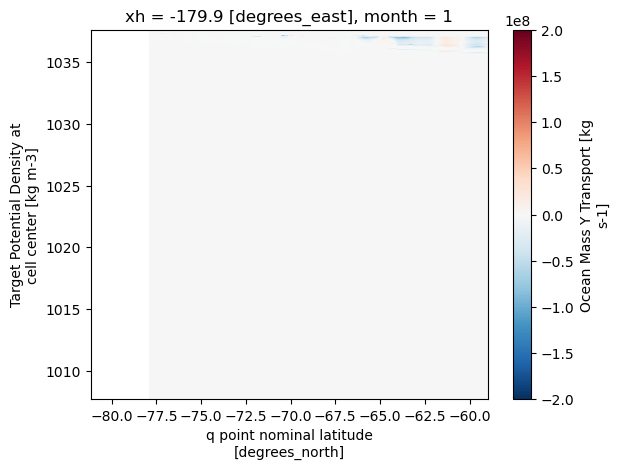

In [79]:
vhrho_nt.isel(xh=1000).isel(month = 0).plot(y='rho2_l')

In [26]:
temp.min().values

array(-2.0103116, dtype=float32)

In [28]:
temp.max().values

array(24.539743, dtype=float32)


It seems like a figure out what the problem is... the temperature looks a little wacky, as we get minimuns of and maximuns of 3110. that should do in termps of explaining our problem. lets try to flag that problem. To fix this problem I will flag the temperature to fit the minimuns and maximuns on Z coords.

Even after flagging the temperatures, the heat transport is kind of bad. I wonder if we could do something else. We can try to bin the temperture (monthly) offline, but that would fige other problems I guess



In [29]:
	#another test with a fake climatology. let's calcualte the transports before the climatology
	# NOTICE THAT AT THIS POINT OF THE ROUTINE NOTHING IS AVERAGED IN TIME
	### creating halos before climatology
	temp_halo = xr.concat((temp.isel(xh=-1), temp),dim = 'xh')
	temp_halo['xh'] = np.concatenate(((temp.xh[0] - temp.xh[0:2].diff('xh')),temp.xh),axis = 0)
	
	#creating temp halo
	temp_halo_int = xr.concat((temp_int.isel(xh=-1), temp_int),dim = 'xh')
	temp_halo_int['xh'] = np.concatenate(((temp_int.xh[0] - temp_int.xh[0:2].diff('xh')),temp_int.xh),axis = 0)
	
	### creating halos before climatology
	vol_halo = xr.concat((volcello.isel(xh=-1), volcello),dim = 'xh')
	vol_halo['xh'] = np.concatenate(((volcello.xh[0] - volcello.xh[0:2].diff('xh')),volcello.xh),axis = 0)
	vol_halo_xgrid = vol_halo.interp(xh = uhrho_et.xq).drop('xh').isel(xq=slice(0,-1))
	vol_halo_ygrid = vol_halo.interp(yh = vhrho_nt.yq).drop('yh').isel(yq=slice(0,-1))
	
	# # calculating temp on grids
	# temp_xgrid = temp_halo.interp(xh = uhrho_et.xq).drop('xh').isel(xq=slice(0,-1))
	# temp_ygrid = temp_halo.interp(yh = vhrho_nt.yq).drop('yh').isel(yq=slice(0,-1))
	
	# calculating temp on grids
	temp_xgrid = (temp_halo * vol_halo).interp(xh = uhrho_et.xq).drop('xh').isel(xq=slice(0,-1))/vol_halo_xgrid
	temp_ygrid = (temp_halo * vol_halo).interp(yh = vhrho_nt.yq).drop('yh').isel(yq=slice(0,-1))/vol_halo_ygrid
	
	# approach 1 with interpolation
	temp_xgrid_int = temp_halo_int.interp(xh = uhrho_et.xq).drop('xh').isel(xq=slice(0,-1))
	temp_ygrid_int = temp_halo_int.interp(yh = vhrho_nt.yq).drop('yh').isel(yq=slice(0,-1))
	
	

In [30]:
	# freezing points transports
	freezing_point_heat_trans_zonal_nonclim = (cp*uhrho_et*temp_freezing)
	freezing_point_heat_trans_meridional_nonclim = (cp*vhrho_nt*temp_freezing)
	freezing_point_heat_trans_zonal_int_nonclim = (cp*uhrho_et_int*temp_freezing)
	freezing_point_heat_trans_meridional_int_nonclim = (cp*vhrho_nt_int*temp_freezing)
	# temperature based transports
	temp_xflux_nonclim = (cp*uhrho_et*temp_xgrid)
	temp_yflux_nonclim = (cp*vhrho_nt*temp_ygrid)
	temp_xflux_int_nonclim = (cp*uhrho_et_int*temp_xgrid_int)
	temp_yflux_int_nonclim = (cp*vhrho_nt_int*temp_ygrid_int)
	
	
	#tempxfluxes and tempyfluxes minus freezing point calculations
	temp_yflux_month_nonclim = (temp_yflux_nonclim - freezing_point_heat_trans_meridional_nonclim).groupby('time.month').mean('time')
	temp_xflux_month_nonclim = (temp_xflux_nonclim - freezing_point_heat_trans_zonal_nonclim).groupby('time.month').mean('time')
	temp_yflux_month_int_nonclim = (temp_yflux_int_nonclim - freezing_point_heat_trans_meridional_int_nonclim).groupby('time.month').mean('time')
	temp_xflux_month_int_nonclim = (temp_xflux_int_nonclim - freezing_point_heat_trans_zonal_int_nonclim).groupby('time.month').mean('time')

In [31]:
	#testing doing the climatology in the vertically integrated layers already
	vhrho_nt_int = vhrho_nt_int.groupby('time.month').mean('time')
	uhrho_et_int = uhrho_et_int.groupby('time.month').mean('time') 
	temp_int = temp_int.groupby('time.month').mean('time') 
	volcello_int = volcello_int.groupby('time.month').mean('time') 


In [32]:
	# climatology
	vhrho_nt = vhrho_nt.sel(yq=lat_range).groupby('time.month').mean('time') #kg/s
	uhrho_et = uhrho_et.sel(yh=lat_range).groupby('time.month').mean('time') #kg/s
	temp = temp.sel(yh=lat_range).groupby('time.month').mean('time') #celsius

In [33]:
	#creating temp halo
	temp_halo = xr.concat((temp.isel(xh=-1), temp),dim = 'xh')
	temp_halo['xh'] = np.concatenate(((temp.xh[0] - temp.xh[0:2].diff('xh')),temp.xh),axis = 0)
	
	#creating temp halo
	temp_halo_int = xr.concat((temp_int.isel(xh=-1), temp_int),dim = 'xh')
	temp_halo_int['xh'] = np.concatenate(((temp_int.xh[0] - temp_int.xh[0:2].diff('xh')),temp_int.xh),axis = 0)


In [34]:
	vhrho_nt_xhlim=np.size(vhrho_nt.xh)
	vhrho_nt_yqlim=np.size(vhrho_nt.yq)
	uhrho_et_xqlim=np.size(uhrho_et.xq)
	uhrho_et_yhlim=np.size(uhrho_et.yh)
	uhrho_et_yhlim

510

In [35]:

	# vmo = cc.querying.getvar(exp,'vmo',session,ncfile='%rho%',frequency='1 monthly',start_time=start_time,\
 #                             end_time=end_time)
	# umo = cc.querying.getvar(exp,'umo',session,ncfile='%rho%',frequency='1 monthly',start_time=start_time,\
 #                             end_time=end_time)


In [36]:
	freezing_point_heat_trans_zonal = (cp*uhrho_et*temp_freezing)
	freezing_point_heat_trans_meridional = (cp*vhrho_nt*temp_freezing)

In [37]:
	freezing_point_heat_trans_zonal_int = (cp*uhrho_et_int*temp_freezing)
	freezing_point_heat_trans_meridional_int = (cp*vhrho_nt_int*temp_freezing)

In [38]:
	# approach 1 with interpolation
	temp_xgrid = temp_halo.interp(xh = freezing_point_heat_trans_zonal.xq).drop('xh').isel(xq=slice(0,-1))
	temp_ygrid = temp_halo.interp(yh = freezing_point_heat_trans_meridional.yq).drop('yh').isel(yq=slice(0,-1))

In [39]:
	# approach 1 with interpolation
	temp_xgrid_int = temp_halo_int.interp(xh = freezing_point_heat_trans_zonal.xq).drop('xh').isel(xq=slice(0,-1))
	temp_ygrid_int = temp_halo_int.interp(yh = freezing_point_heat_trans_meridional.yq).drop('yh').isel(yq=slice(0,-1))

In [40]:
	# #attributing the temperature to the right grid point
	# temp_xgrid = temp.copy()
	# temp_xgrid = temp_xgrid.rename({'xh':'xq'})
	# temp_xgrid['xq'] = uhrho_et.xq[:-1]
	
	
	# temp_ygrid = temp.copy()
	# temp_ygrid = temp_ygrid.rename({'yh':'yq'})
	# temp_ygrid['yq'] = vhrho_nt.yq[:-1]

In [41]:
	# #attributing the temperature to the right grid point - integrated case
	# temp_xgrid_int = temp_int.copy()
	# temp_xgrid_int = temp_xgrid_int.rename({'xh':'xq'})
	# temp_xgrid_int['xq'] = uhrho_et_int.xq[:-1]
	
	
	# temp_ygrid_int = temp_int.copy()
	# temp_ygrid_int = temp_ygrid_int.rename({'yh':'yq'})
	# temp_ygrid_int['yq'] = vhrho_nt_int.yq[:-1]

calculating the climatology of the CSHT

In [42]:
	temp_xflux = (cp*uhrho_et*temp_xgrid)
	temp_yflux = (cp*vhrho_nt*temp_ygrid)

In [43]:
	temp_xflux_int = (cp*uhrho_et_int*temp_xgrid_int)
	temp_yflux_int = (cp*vhrho_nt_int*temp_ygrid_int)

Notice that xq[0] and xq[-1] are the same value (-280, and 80). therefore we can just delete one of the edges. For consistency with the OM2-01 (MOM5) grid, I will delete the first value of xq, so we have the grid starting at the center of the xh cells, and ending at the edge of the xq cells. The same thing for latitudes, in OM2 yt_ocean is south of yu_ocean, so we will cut off the first value of yq

In [44]:
	xmax=int(np.size(temp_xflux.xq))
	ymax=int(np.size(freezing_point_heat_trans_meridional.yq.sel(yq=slice(-90,-59))))

Now we have to cut off the depth to agree too (zl)

In [45]:
	
	# Before making the difference, make sure you are cutting z_l in the same level on temp_fluxes
	print("Removing freezing point heat transport")
	# compare both ways:
	temp_yflux_month = temp_yflux - freezing_point_heat_trans_meridional
	temp_xflux_month = temp_xflux - freezing_point_heat_trans_zonal
	
	
	#temp_yflux_month = temp_yflux_month.isel(yq=slice(0,ymax-1))
	#temp_xflux_month = temp_xflux_month.isel(xq=slice(0,xmax-1))
	
	
	#ndays_month=int(monthdays[int(int(2)-1)]) ###############################################################
	print('number of days in the current month = ' +str(freezing_point_heat_trans_zonal.month.size))
	

Removing freezing point heat transport
number of days in the current month = 12


In [46]:
	temp_yflux_month_int = temp_yflux_int - freezing_point_heat_trans_meridional_int
	temp_xflux_month_int = temp_xflux_int - freezing_point_heat_trans_zonal_int

In [47]:
	%%time 
	temp_yflux_month.load()
	temp_xflux_month.load()
	cutout_latind=ymax-1
	print('loaded heat transports')

loaded heat transports
CPU times: user 16min 8s, sys: 2min 27s, total: 18min 35s
Wall time: 18min 57s


In [48]:
	temp_yflux_month_int.load()
	temp_xflux_month_int.load()
	print('loaded integrated heat transports')

loaded integrated heat transports


In [49]:
	temp_yflux_month_nonclim.load()
	temp_xflux_month_nonclim.load()
	print('loaded integrated heat transports')

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
 

loaded integrated heat transports


In [50]:
	temp_yflux_month_int_nonclim.load()
	temp_xflux_month_int_nonclim.load()
	print('loaded integrated heat transports')

loaded integrated heat transports


In [51]:
	########### Import panan01 1km contour                
	outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan01_'+str(isobath_depth)+'m.npz'
	data = np.load(outfile)
	mask_y_transport = data['mask_y_transport']; 
	mask_y_transport=mask_y_transport[:cutout_latind,:]       ##############################
	mask_x_transport = data['mask_x_transport']; 
	mask_x_transport=mask_x_transport[:cutout_latind,:]		################################
	mask_y_transport_numbered = data['mask_y_transport_numbered']
	mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################
	mask_x_transport_numbered = data['mask_x_transport_numbered']
	mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################
	
	
	#cutting the matrices
	ylength= np.shape(mask_x_transport)[0]
	
	
	yh0 = cc.querying.getvar(exp,'yh',session,n=1)
	yh0 = yh0.isel(yh=slice(0,ylength))
	yq0 = cc.querying.getvar(exp,'yq',session,n=1).isel(yq=slice(1,ymax))
	#yq0 = yq0.isel(yq=slice(0,ylength))
	xh0 = cc.querying.getvar(exp,'xh',session,n=1)
	xq0 = cc.querying.getvar(exp,'xq',session,n=1).isel(xq=slice(1,xmax+1))

In [52]:
	mask_x_transport =xr.DataArray(data['mask_x_transport']).assign_coords({"dim_0": np.array(yh0),"dim_1": np.array(xq0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
	#mask_x_transport=mask_x_transport[:cutout_latind,:]       ##############################
	mask_y_transport =xr.DataArray(data['mask_y_transport']).assign_coords({"dim_0": np.array(yq0),"dim_1": np.array(xh0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
	#mask_y_transport=mask_y_transport[:cutout_latind,:]		################################		
	mask_x_transport_numbered =xr.DataArray(data['mask_x_transport_numbered']).assign_coords({"dim_0": np.array(yh0),"dim_1": np.array(xq0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
	#mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################		
	mask_y_transport_numbered =xr.DataArray(data['mask_y_transport_numbered']).assign_coords({"dim_0": np.array(yq0),"dim_1": np.array(xh0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
	#mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################
	
	num_points = int(np.maximum(np.max(mask_y_transport_numbered),np.max(mask_x_transport_numbered)))                
	
	
	
	
	############### Getting the lon,lat along contour in the X,Y contour
	lat_along_contour = np.zeros((num_points))
	lon_along_contour = np.zeros((num_points))
	# locations for zonal transport:
	x_indices_masked = mask_x_transport_numbered.stack().values
	x_indices = np.sort(x_indices_masked[x_indices_masked>0])
	for count in x_indices:
		count = int(count)
		jj = int(np.where(mask_x_transport_numbered==count)[0])
		ii = int(np.where(mask_x_transport_numbered==count)[1])   
		lon_along_contour[count-1] = xq0[ii].values
		lat_along_contour[count-1] = mask_x_transport_numbered.y_ocean[jj].values
		
	# locations for meridional transport:
	y_indices_masked = mask_y_transport_numbered.stack().values
	y_indices = np.sort(y_indices_masked[y_indices_masked>0])
	for count in y_indices:
		count = int(count)
		jj = np.where(mask_y_transport_numbered==count)[0]
		ii = np.where(mask_y_transport_numbered==count)[1]
		lon_along_contour[count-1] = mask_x_transport_numbered.x_ocean[ii].values           ##################          ##################          ##################          ##################          ##################          ##################
		lat_along_contour[count-1] = yq0[jj].values
	

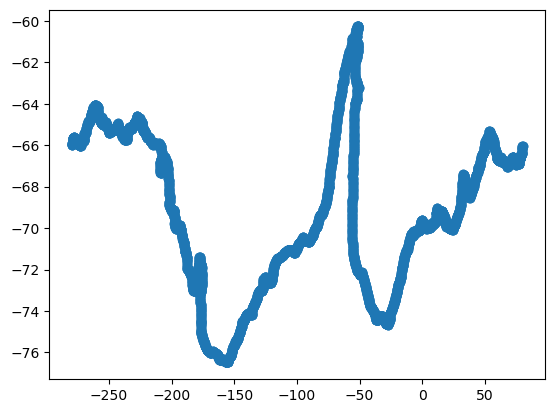

In [53]:
plt.scatter(lon_along_contour,lat_along_contour)

In [54]:
	temp_yflux_with_mask_month=temp_yflux_month.copy()
	temp_yflux_with_mask_month['yq'] = np.array(mask_y_transport.y_ocean)
	temp_yflux_with_mask_month['xh'] = np.array(mask_y_transport.x_ocean)
	temp_yflux_with_mask_month = temp_yflux_with_mask_month.rename(yq='y_ocean',xh='x_ocean')*mask_y_transport
	
	temp_xflux_with_mask_month=temp_xflux_month.copy()
	temp_xflux_with_mask_month['yh'] = np.array(mask_y_transport.y_ocean)
	temp_xflux_with_mask_month['xq'] = np.array(mask_y_transport.x_ocean)
	temp_xflux_with_mask_month = temp_xflux_with_mask_month.rename(yh='y_ocean',xq='x_ocean')*mask_y_transport
	
	
	temp_yflux_with_mask_month['y_ocean']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_with_mask_month['x_ocean']=np.array(mask_y_transport_numbered.x_ocean)
	
	temp_xflux_with_mask_month['y_ocean']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_with_mask_month['x_ocean']=np.array(mask_x_transport_numbered.x_ocean)

In [55]:
	# INT
	temp_yflux_with_mask_month_int=temp_yflux_month_int.copy()
	temp_yflux_with_mask_month_int['yq'] = np.array(mask_y_transport.y_ocean)
	temp_yflux_with_mask_month_int['xh'] = np.array(mask_y_transport.x_ocean)
	temp_yflux_with_mask_month_int = temp_yflux_with_mask_month_int.rename(yq='y_ocean',xh='x_ocean')*mask_y_transport
	
	temp_xflux_with_mask_month_int=temp_xflux_month_int.copy()
	temp_xflux_with_mask_month_int['yh'] = np.array(mask_y_transport.y_ocean)
	temp_xflux_with_mask_month_int['xq'] = np.array(mask_y_transport.x_ocean)
	temp_xflux_with_mask_month_int = temp_xflux_with_mask_month_int.rename(yh='y_ocean',xq='x_ocean')*mask_y_transport
	
	
	temp_yflux_with_mask_month_int['y_ocean']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_with_mask_month_int['x_ocean']=np.array(mask_y_transport_numbered.x_ocean)
	
	temp_xflux_with_mask_month_int['y_ocean']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_with_mask_month_int['x_ocean']=np.array(mask_x_transport_numbered.x_ocean)

In [56]:
	# Create the contour order data-array. Note that in this procedure the x-grid counts have x-grid
	#   dimensions and the y-grid counts have y-grid dimensions, but these are implicit, the dimension 
	#   *names* are kept general across the counts, the generic y_ocean, x_ocean, so that concatening works
	#   but we dont double up with numerous counts for one lat/lon point.
	
	# stack contour data into 1d:
	mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
	mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)
	
	mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
	mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)
	
	contour_ordering = xr.concat((mask_x_numbered_1d, mask_y_numbered_1d), dim = 'contour_index')
	contour_ordering = contour_ordering.sortby(contour_ordering)
	contour_index_array = np.arange(1, len(contour_ordering)+1)

In [57]:
	temp_yflux_month['yq']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_month['xh']=np.array(mask_y_transport_numbered.x_ocean)
	
	
	temp_xflux_month['yh']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_month['xq']=np.array(mask_x_transport_numbered.x_ocean)

In [58]:
	temp_yflux_month_int['yq']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_month_int['xh']=np.array(mask_y_transport_numbered.x_ocean)
	
	
	temp_xflux_month_int['yh']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_month_int['xq']=np.array(mask_x_transport_numbered.x_ocean)

In [59]:
temp_yflux_month_nonclim = temp_yflux_month_nonclim.isel(yq=slice(0,510))

In [60]:
temp_xflux_month_nonclim = temp_xflux_month_nonclim.isel(yh=slice(0,510))

In [61]:
	temp_yflux_month_nonclim['yq']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_month_nonclim['xh']=np.array(mask_y_transport_numbered.x_ocean)
	
	
	temp_xflux_month_nonclim['yh']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_month_nonclim['xq']=np.array(mask_x_transport_numbered.x_ocean)

In [62]:
temp_yflux_month_int_nonclim = temp_yflux_month_int_nonclim.isel(yq=slice(0,510))

In [63]:
	temp_yflux_month_int_nonclim['yq']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_month_int_nonclim['xh']=np.array(mask_y_transport_numbered.x_ocean)
	
	
	temp_xflux_month_int_nonclim['yh']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_month_int_nonclim['xq']=np.array(mask_x_transport_numbered.x_ocean)

In [64]:
	# stack transports into 1d and drop any points not on contour:
	x_along_1d = mask_x_transport.stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d = x_along_1d.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d = mask_y_transport.stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d = y_along_1d.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour, to obtain a matrix with transport directions:
	transp_dir = xr.concat((x_along_1d, y_along_1d), dim = 'contour_index')
	transp_dir = transp_dir.sortby(contour_ordering)
	transp_dir.coords['contour_index'] = contour_index_array
	transp_dir = transp_dir.load()

In [65]:
	## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.
	# stack transports into 1d and drop any points not on contour:
	x_along_1d = temp_xflux_month.rename(yh='y_ocean',xq='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d = x_along_1d.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d = temp_yflux_month.rename(yq='y_ocean',xh='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d = y_along_1d.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour:
	heat_transp_across_contour = xr.concat((x_along_1d, y_along_1d), dim = 'contour_index')
	heat_transp_across_contour = heat_transp_across_contour.sortby(contour_ordering)
	heat_transp_across_contour.coords['contour_index'] = contour_index_array
	heat_transp_across_contour = (heat_transp_across_contour*transp_dir).load()

In [66]:
	## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.
	# stack transports into 1d and drop any points not on contour:
	x_along_1d_int = temp_xflux_month_int.rename(yh='y_ocean',xq='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d_int = x_along_1d_int.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d_int = temp_yflux_month_int.rename(yq='y_ocean',xh='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d_int = y_along_1d_int.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour:
	heat_transp_across_contour_int = xr.concat((x_along_1d_int, y_along_1d_int), dim = 'contour_index')
	heat_transp_across_contour_int = heat_transp_across_contour_int.sortby(contour_ordering)
	heat_transp_across_contour_int.coords['contour_index'] = contour_index_array
	heat_transp_across_contour_int = (heat_transp_across_contour_int*transp_dir).load()

In [67]:
	## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.
	# stack transports into 1d and drop any points not on contour:
	x_along_1d_nonclim = temp_xflux_month_nonclim.rename(yh='y_ocean',xq='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d_nonclim = x_along_1d_nonclim.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d_nonclim = temp_yflux_month_nonclim.rename(yq='y_ocean',xh='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d_nonclim = y_along_1d_nonclim.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour:
	heat_transp_across_contour_nonclim = xr.concat((x_along_1d_nonclim, y_along_1d_nonclim), dim = 'contour_index')
	heat_transp_across_contour_nonclim = heat_transp_across_contour_nonclim.sortby(contour_ordering)
	heat_transp_across_contour_nonclim.coords['contour_index'] = contour_index_array
	heat_transp_across_contour_nonclim = (heat_transp_across_contour_nonclim*transp_dir).load()

In [68]:
	## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.
	# stack transports into 1d and drop any points not on contour:
	x_along_1d_int_nonclim = temp_xflux_month_int_nonclim.rename(yh='y_ocean',xq='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d_int_nonclim = x_along_1d_int_nonclim.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d_int_nonclim = temp_yflux_month_int_nonclim.rename(yq='y_ocean',xh='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d_int_nonclim = y_along_1d_int_nonclim.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour:
	heat_transp_across_contour_int_nonclim = xr.concat((x_along_1d_int_nonclim, y_along_1d_int_nonclim), dim = 'contour_index')
	heat_transp_across_contour_int_nonclim = heat_transp_across_contour_int_nonclim.sortby(contour_ordering)
	heat_transp_across_contour_int_nonclim.coords['contour_index'] = contour_index_array
	heat_transp_across_contour_int_nonclim = (heat_transp_across_contour_int_nonclim*transp_dir).load()

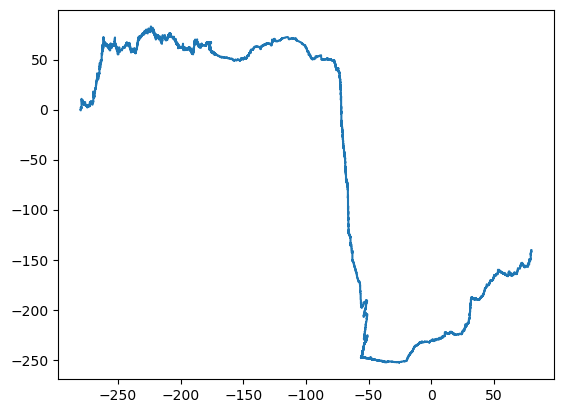

In [73]:
plt.plot(lon_along_contour,
         heat_transp_across_contour_int_nonclim.mean('month').cumsum('contour_index')/1e12)

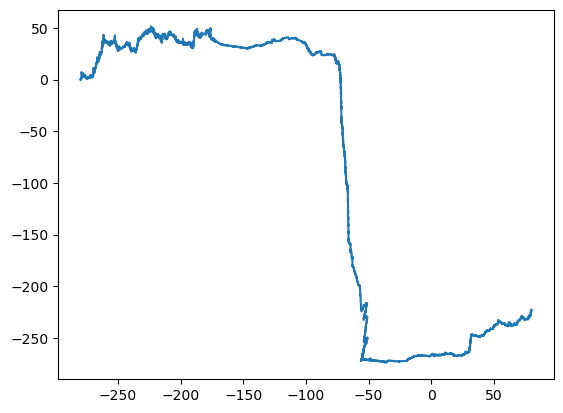

In [70]:
plt.plot(lon_along_contour,
         heat_transp_across_contour_nonclim.sum('rho2_l').mean('month').cumsum('contour_index')/1e12)

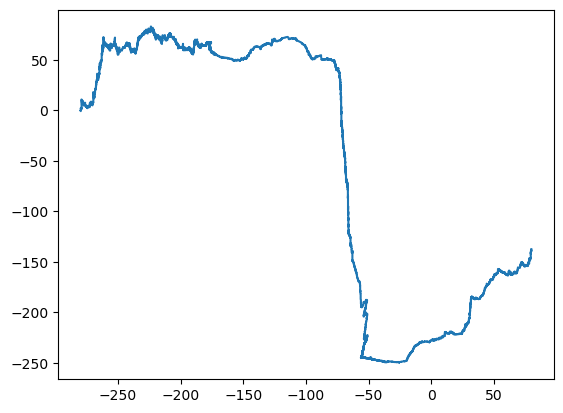

In [71]:
plt.plot(lon_along_contour,
         heat_transp_across_contour_int.mean('month').cumsum('contour_index')/1e12)

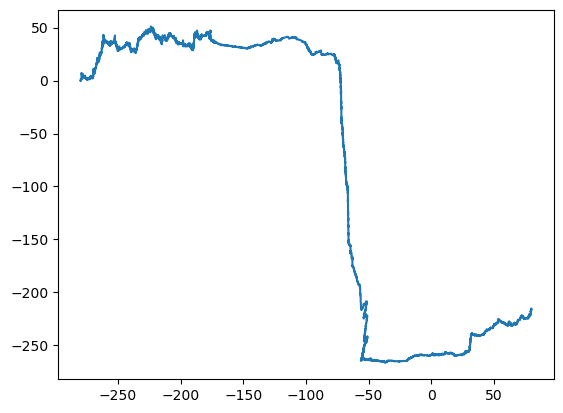

In [72]:
plt.plot(lon_along_contour,
         heat_transp_across_contour.sum('rho2_l').mean('month').cumsum('contour_index')/1e12)

Look at this - it worked! and it gives values vary similar to the 60 TW from OM2!

In [22]:
	# convert to longitude coordinate and average into 3 degree longitude bins:
	# in degrees:
	bin_width = 3
	bin_spacing = 0.25
	lon_west = -280
	lon_east = 80
	
	# new coordinate and midpoints of longitude bins:
	full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
	lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
	n_bin_edges = len(full_lon_coord)
	
	# sum into longitude bins:
	# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
	# on the isobath contour and sum continously along contour between defined indices.
	# (i.e. lon_along_contour is not monotonic)
	# find points on contour to define edges of longitude bins:
	bin_edge_indices = np.zeros(n_bin_edges)
	for lon_bin in range(n_bin_edges-1):
		# find first isobath point that has the right longitude:
		first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
		# then find all other isobath points with the same longitude as that first point:
		same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
		# we want the most southerly of these points on the same longitude line:
		bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]
	
	# define east/west edges:
	bin_edge_indices = bin_edge_indices.astype(int)
	bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
	bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
	n_bins = len(bin_edge_indices_west)
	
	# sum heat transport from isobath coord into new longitude coord:
	cross_slope_heat_trans = np.zeros([99,n_bins])
	for lon_bin in range(n_bins):
		heat_trans_this_bin0 = heat_transp_across_contour[:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
		cross_slope_heat_trans[:,lon_bin] = np.sum(heat_trans_this_bin0,axis=1)
	
	#cross_slope_heat_trans=np.zeros([ndays_month,75,int(np.size(lon_bin_midpoints))])	
	#cross_slope_heat_trans[ndindex][nzindex]=cross_slope_heat_trans0
	# find average latitude of each bin, so we can plot back on the isobath:
	lat_bin_midpoints = np.zeros(n_bins)
	for lon_bin in range(n_bins):
		# find nearest isobath point:
		lon_index = np.where(lon_along_contour>=lon_bin_midpoints[lon_bin])[0][0]
		lat_bin_midpoints[lon_bin] = lat_along_contour[lon_index]
	
	print('Calculating Zonal heat convergence')
	# Need to make sure the zonal boundaries here match exactly with the zonal boundaries used for the 
	# longitude averaging above, by using same bin_edge_indices.
	# Just check if isobath point is on x or y grid. if x, sum up to this point from south.
	# if on y grid, sum zonal transport on nearest u grid point to west.
	
	zonal_heat_trans_west = np.zeros([99,n_bins])
	for lon_bin in range(n_bins):
		# west limit:
		# reset these to False:
		on_x_grid = False
		on_y_grid = False
		# mask_x_transport_numbered etc indexing starts from 1 not 0, so add 1:
		isobath_west_index = int(bin_edge_indices_west[lon_bin]+1)
		# check if the point is on the x or y transport grid:
		if len(np.where(mask_x_transport_numbered==isobath_west_index)[0])>0:
			on_x_grid = True
			jj = int(np.where(mask_x_transport_numbered==isobath_west_index)[0])
			ii = int(np.where(mask_x_transport_numbered==isobath_west_index)[1])
		elif len(np.where(mask_y_transport_numbered==isobath_west_index)[0])>0:
			on_y_grid = True
			jj = int(np.where(mask_y_transport_numbered==isobath_west_index)[0])
			ii = int(np.where(mask_y_transport_numbered==isobath_west_index)[1])               
		if on_x_grid == True:
			zonal_heat_trans_west[:,lon_bin] = np.sum(temp_xflux_month[:,:jj,ii],axis=1)
		#in this case we want transport half a grid point to the west:
		elif on_y_grid == True:
			# careful if ii=0, then we need heat trans from lon=80, because at limit of zonal grid
			if ii==0:
				zonal_heat_trans_west[:,lon_bin] = np.sum(temp_xflux_month[:,:jj+1,-1],axis=1)
			else:
				zonal_heat_trans_west[:,lon_bin] = np.sum(temp_xflux_month[:,:jj+1,ii-1],axis=1)
	
	zonal_heat_trans_east = np.zeros([99,n_bins])
	for lon_bin in range(n_bins):
		# east limit:
		# reset these to False:
		on_x_grid = False
		on_y_grid = False
		# mask_x_transport_numbered etc indexing starts from 1 not 0, so add 1:
		isobath_east_index = int(bin_edge_indices_east[lon_bin]+1)
		# check if the point is on the x or y transport grid:
		if len(np.where(mask_x_transport_numbered==isobath_east_index)[0])>0:
			on_x_grid = True
			jj = int(np.where(mask_x_transport_numbered==isobath_east_index)[0])
			ii = int(np.where(mask_x_transport_numbered==isobath_east_index)[1])
		elif len(np.where(mask_y_transport_numbered==isobath_east_index)[0])>0:
			on_y_grid = True
			jj = int(np.where(mask_y_transport_numbered==isobath_east_index)[0])
			ii = int(np.where(mask_y_transport_numbered==isobath_east_index)[1])
		if on_x_grid == True:
			zonal_heat_trans_east[:,lon_bin] = np.sum(temp_xflux_month[:,:jj,ii],axis=1)
			# in this case we want transport half a grid point to the west:
		elif on_y_grid == True:
			# wrap around to east side of grid:
			if ii==0:
				zonal_heat_trans_east[:,lon_bin] = np.sum(temp_xflux_month[:,:jj+1,-1],axis=1)
			else:
				zonal_heat_trans_east[:,lon_bin] = np.sum(temp_xflux_month[:,:jj+1,ii-1],axis=1)
	
	zonal_convergence = zonal_heat_trans_east - zonal_heat_trans_west

Calculating Zonal heat convergence


## Saving

In [23]:
	# save_dir  = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/CSHT_month_rhoonline/Ant_cross_slope_heat_terms_offline_'+str(isobath_depth)+'m_'+ start_time+'.nc'    
	
	
	# data_ZC=xr.DataArray((zonal_convergence),name="zonal_convergence",dims=["rho2_l","lon_bin_midpoints"])
	# data_CSHT=xr.DataArray((cross_slope_heat_trans),name="binned_cross_slope_heat_trans",dims=["rho2_l","lon_bin_midpoints"])
	# data_HT=heat_transp_across_contour
	# data_HT.name='unbinned_heat_transp_across_contour'
	# data_lat=xr.DataArray((lat_along_contour),name="lat_along_contour",dims=["contour_index"])
	# data_lon=xr.DataArray((lon_along_contour),name="lon_along_contour",dims=["contour_index"])
	# data_latbin=xr.DataArray((lat_bin_midpoints),name="lat_bin_midpoints",dims=["lon_bin_midpoints"])
	
	# #data_time=xr.DataArray(Ualong.time,name="time",dims=["time"])
	
	# data_to_saveuv = xr.merge([data_ZC,data_CSHT,data_HT,data_lat,data_lon,data_latbin])
	# data_to_saveuv['contour_index']=heat_transp_across_contour.contour_index
	# data_to_saveuv['rho2_l']=np.array(heat_transp_across_contour.rho2_l)
	# data_to_saveuv['lon_bin_midpoints']=np.array(lon_bin_midpoints)
	# data_to_saveuv['time']=heat_transp_across_contour.time
	# data_to_saveuv.to_netcdf(save_dir,mode='w')
	
	# print('Finished successful')

Finished successful


testing the organizing data

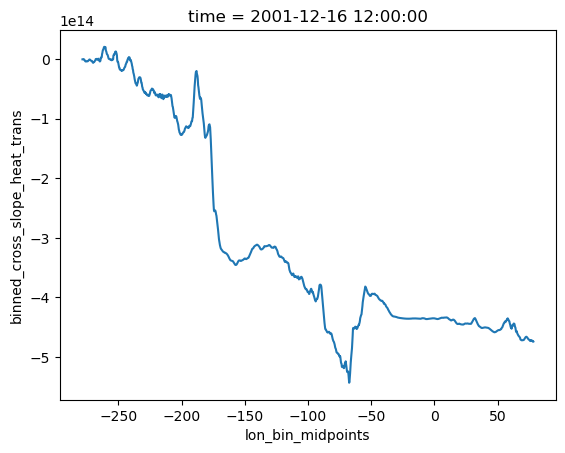

In [24]:
data_to_saveuv.binned_cross_slope_heat_trans.sum('rho2_l').cumsum().plot()

# Checking it

This part doesnt go to the main python code

In [25]:
factor= float(np.sum(np.mean(heat_transp_across_contour,axis=0)) /(np.nansum(np.nansum(np.mean(cross_slope_heat_trans,axis=0),axis=0)) +
                                                     np.nansum(np.nansum(np.mean(zonal_convergence,axis=0),axis=0))))
factor

0.08272005777949555

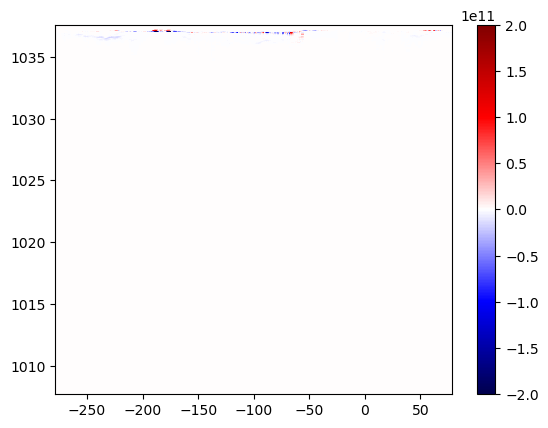

In [26]:
plt.pcolormesh(data_to_saveuv.lon_bin_midpoints,data_to_saveuv.rho2_l,
               data_to_saveuv.binned_cross_slope_heat_trans*factor,cmap='seismic',vmin=-2e11,vmax=2e11)
plt.colorbar()

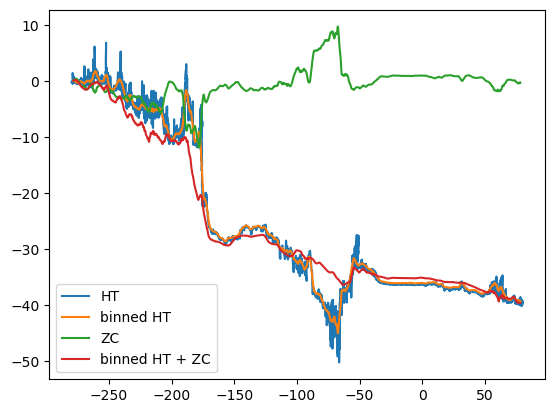

In [27]:
HT=np.cumsum(np.nansum(heat_transp_across_contour,axis=0))
CSHT=np.cumsum(np.nansum(cross_slope_heat_trans,axis=0))*factor
CSHT_ZC=np.cumsum(np.nansum(cross_slope_heat_trans+zonal_convergence,axis=0))*factor
ZC=np.cumsum(np.nansum(zonal_convergence,axis=0))*factor

plt.plot(lon_along_contour,HT/1e12,label='HT')
plt.plot(lon_bin_midpoints,CSHT/1e12,label='binned HT')
plt.plot(lon_bin_midpoints,ZC/1e12,label='ZC')
plt.plot(lon_bin_midpoints,CSHT_ZC/1e12,label='binned HT + ZC')
# 
plt.legend()

In [28]:
start_time

'2001-12'